## Outcome devaluation and habit expression
Here I want to take a different approach, compared to previous experiment, where we actually model a two-stage trial. This allows me to look at the role of planning and talk about habituation of sequences.

In this paper authors showed that when you train two actions concurrently (need to still define this group in terms of simulation parameters and make some predictions about what will happen), neither of them gets expressed as habit. When you train and devalue only 1, you can show a habit. I will try and recreate the simulations. 

![alt text](img1_exp_design.png)


### Group 1 - has 1 action 

Environment:
Reward contingenciesrepresent the probability of outcomes O1, O2 or ~O given actions A1 or ~A1 and are as follows during training and extinction, respectivelly:


\begin{bmatrix} 0.9  & 0   \\ 0    & 0.5  \\ 0.1  & 0.5 \end{bmatrix}, \begin{bmatrix} 0  & 0   \\ 0  & 0  \\ 1  & 1 \end{bmatrix}



During training the outcome preference $p(\bar{o})$ is $\left[0.45,0.45,0.1\right]$ and during devaluation we have 2 groups, one where the habit-associated outcome is devalued and one where the non-contingent outcome is devalued:

$p(\bar{o}_{h})=\left[0.1,0.8,0.1\right]$, $p(\bar{o}_{n})=\left[0.8,0.1,0.1\right]$

I can explore here building habit only over 1 action!

### Group 2 - has 2 actions


Environment:
Reward contingenciesrepresent the probability of outcomes O1, O2 or ~O given actions A1, A2 or ~A and are as follows during training and extinction, respectivelly:


\begin{bmatrix} 0.9  & 0    & 0    \\ 0    & 0.9  & 0    \\ 0.1  & 0.1 & 1 \end{bmatrix}, \begin{bmatrix} 0  & 0   & 0   \\ 0  & 0  & 0   \\ 1  & 1 & 1   \end{bmatrix}



During training the outcome preference $p(\bar{o})$ is $\left[0.45,0.45,0.1\right]$ and during devaluation we again have 2 groups, with $p(\bar{o}_{h})=\left[0.1,0.8,0.1\right]$, $p(\bar{o}_{n})=\left[0.8,0.1,0.1\right]$


This is the pattern of behaviour from the paper:

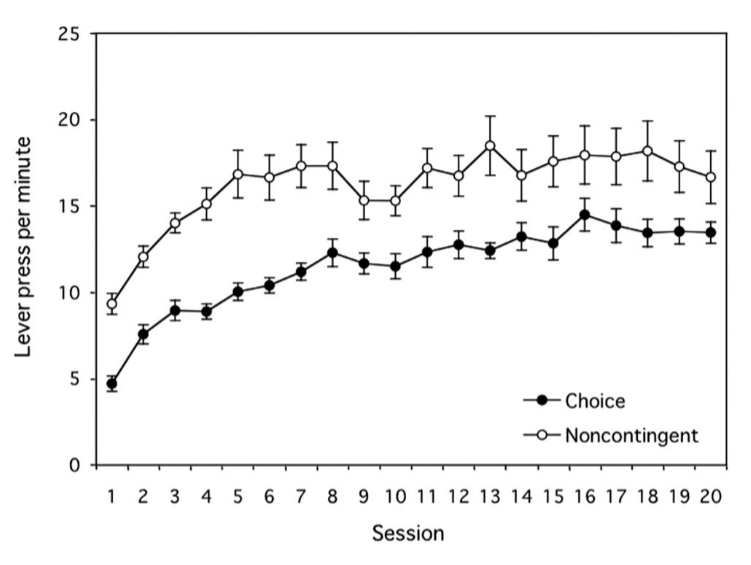

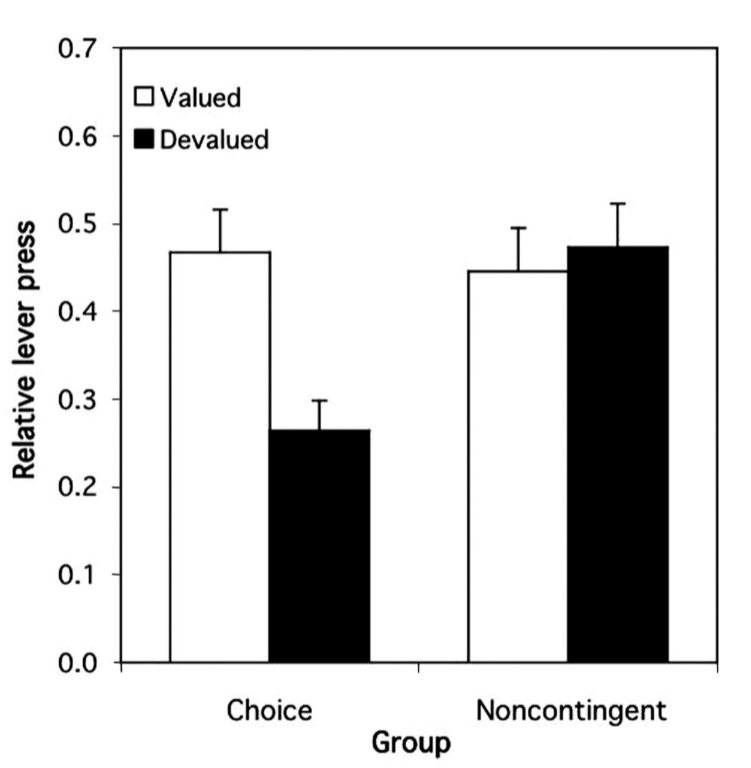



## Group 1 no habit

In the first version of this I set it up where the agent only learns to associate reward with the state of entering magazine. This of course does not work, because policies that say visit magazine as much as possible dominate, because animal does not learn the contingency between action and reward. In order to achieve this I need to add another state for the magazine, effectively defining a full and empty magazine and potentially also learn pertinent state transitions.

So, in the code I need to:

1. Expand state transition matrix to something like this. Optimally the agent learns the probability of transitioning into an empty or full magazine depending on action or 

a = L1
	L1 ~L1 MF ME IS
 L1 1   1  1  1   1
~L1 0   0  0  0   0
 ME 0   0  0  0   0
 MF 0   0  0  0   0
 IS 0   0  0  0   0

a = ~L1
	L1 ~L1 MF ME IS
 L1 0   0  0  0   0
~L1 1   1  1  1   1
 ME 0   0  0  0   0
 MF 0   0  0  0   0
 IS 0   0  0  0   0

a = M
	L1   ~L1   MF ME IS
 L1 0     0    0  0   0
~L1 0     0    0  0   0
 ME 0.5   0.5  1  1   1
 MF 0.5   0.5  0  0   0
 IS 0     0    0  0   0

This also did not work, since agent could not learn the fact that one action leads to outcome 1 and another action to outcome 2 in group 2. So instead we now learn the transition to states magazine empty, magazine full O1, magazine full O2
 

In [1]:
# %matplotlib widget
import matplotlib.pyplot as plt
# import ipywidgets
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.special as scp
from itertools import product
from matplotlib.ticker import MultipleLocator
from scipy.optimize import curve_fit
from concurrent.futures import ProcessPoolExecutor
from run_sim import *
np.set_printoptions(suppress=True)

sns.set_style("whitegrid")
np.seterr(divide='ignore', invalid='ignore')
np.seterr(over='ignore', invalid='ignore')

{'divide': 'ignore', 'over': 'ignore', 'under': 'ignore', 'invalid': 'ignore'}

/home/sia/ContextualSUD/notebooks/8_devaluation_Kosaki_2010/run_sim.py:916: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  g.xaxis.set_ticklabels(policy_mapping, rotation=45)


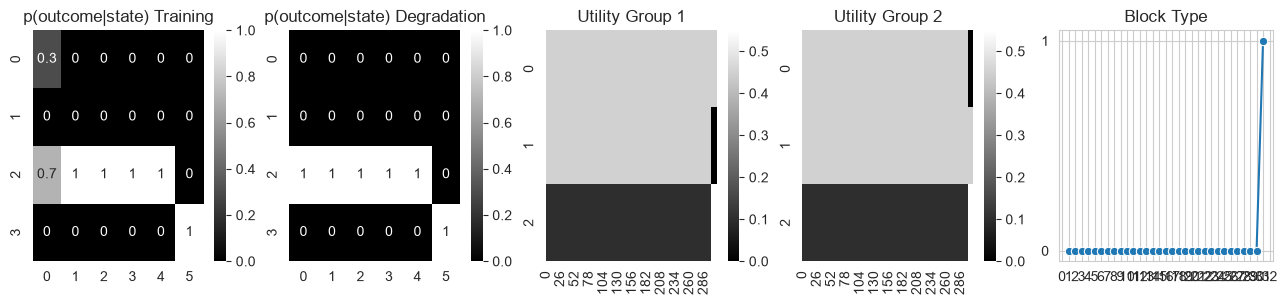

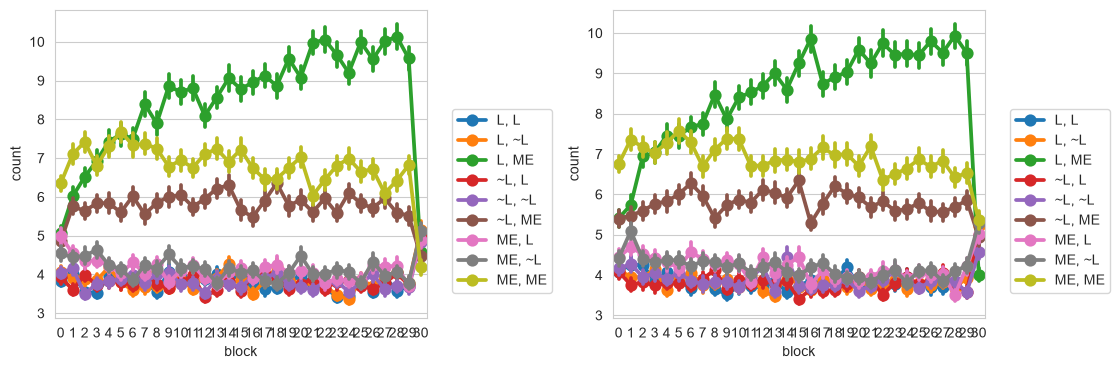

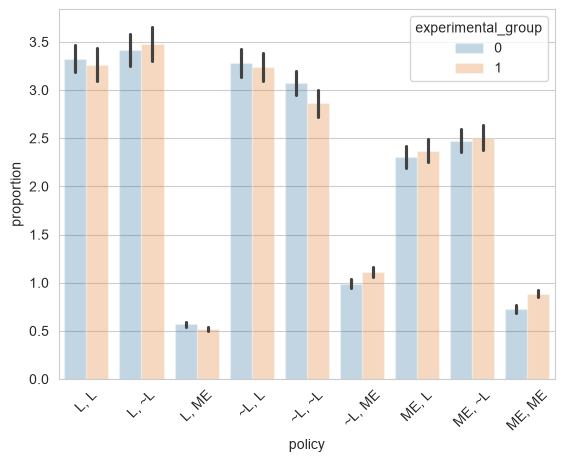

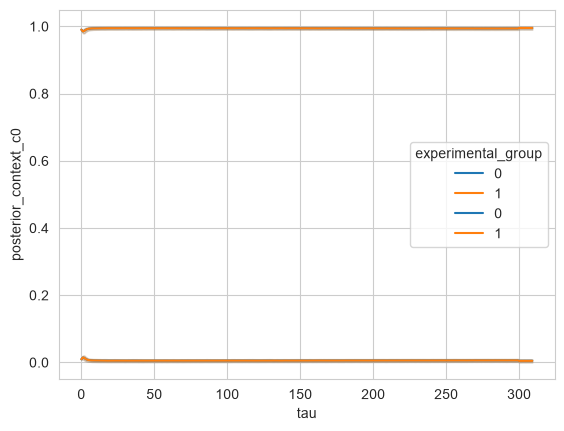

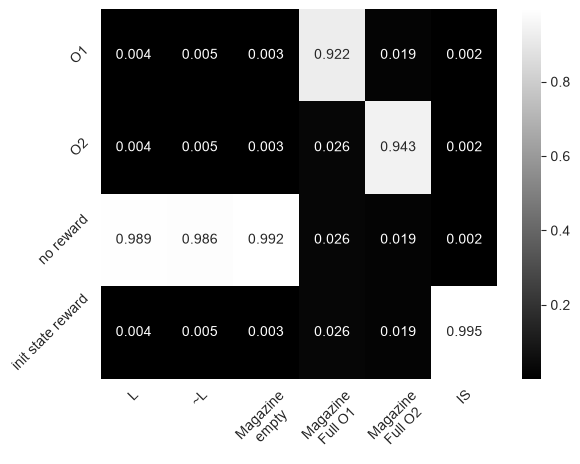

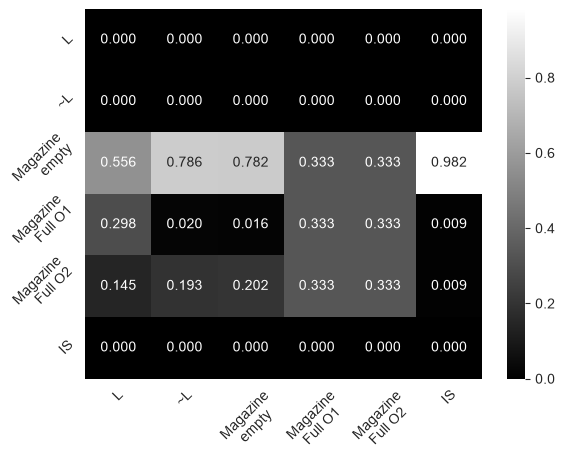

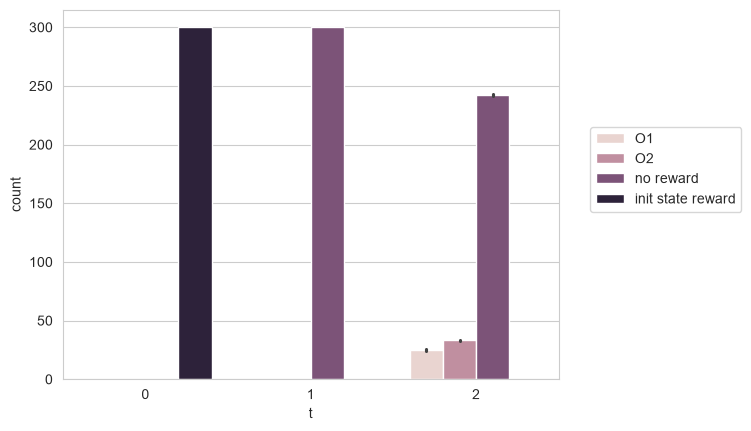

In [16]:

np.random.seed(3)

reps = 200
n_blocks_train = 30
n_blocks_extinction = 1
block_length = 10
n_train = n_blocks_train*block_length
n_extinction = n_blocks_extinction*block_length

TAU = n_train + n_extinction
T = 3  # initial time point, action 1, action 2
na = 3 # L1, ~L1, magazine entry
ns = 6 # L1, ~L1, empty magazine, full magazine o1, full magazine o2, initial state
nr = 4 # pellet, sugar, no reward, initial state

max_workers = 62

debug = False
parallel = True

p = 0.45
rho_noncontingent = 0.2
rho = 0.3
context_volatility = 0.99
h = 1000
dec_temp = 2

utility_1 = [[0.45,0.45, 0.1], [p, 0, 1-p]]
utility_2 = [[0.45,0.45, 0.1], [0, p, 1-p]]

# outcomes: O1=pellets, O2=sugar, O3= no reward, O4=starting outcome, probably don't really need it
# states: L1, ~L1, magazine entry, initial state in front lever
Rho = np.stack([[[rho  , 0.0, 0.0, 0.0, 0.0, 0.0],
				 [0    , 0.0, 0.0, 0.0, 0.0, 0.0],
				 [1-rho, 1.0, 1.0, 1.0, 1.0, 0.0],
				 [0.0  , 0.0, 0.0, 0.0, 0.0, 1.0]],
				[[0, 0, 0, 0, 0, 0],
				 [0, 0, 0, 0, 0, 0],
				 [1, 1, 1, 1, 1, 0],
				 [0, 0, 0, 0, 0, 1]]], axis=-1)

habit_exception = None


long_dfs = []
pars = []
matrices = {"state_transition_matrix": np.zeros([ns,ns,reps*2]), "reward_generation_matrix": np.zeros([nr,ns,reps*2])}

sim = 0
for rep in range(reps):
	for group, util in enumerate([utility_1,utility_2]):
		pars.append({
			"debug": debug, 
			"util": util, 
			"na": na, 
			"ns": ns, 
			"T": T, 
			"n_train": n_train, 
			"n_extinction": n_extinction, 
			"Rho": Rho,
			"rho_noncontingent": rho_noncontingent,
			"utility_1": utility_1,
			"utility_2": utility_2,
			"context_volatility": context_volatility, 
			"h": h,
			"dec_temp":dec_temp, 
			"habit_exception": habit_exception,
			"TAU":TAU,
			"sim": sim,
			"group":group,
			"rep": rep,
			"n_blocks_extinction": n_blocks_extinction,
			"n_blocks_train": n_blocks_train,
			"block_length": block_length,
			"state_mapping": {"lever_press":0, "no_lever_press":1, "magazine_empty":2, "magazine_full_O1":3, "magazine_full_O2":4, "initial_state":5},
			"action_mapping": {"lever_press":0, "no_lever_press":1, "magazine_entry":2},
			"reward_mapping": {"outcome_1":0, "outcome_2":1, "no_reward":2, "initial_state":3},
			"action_legend_labels":["L", "~L", "ME"],
			"state_legend_labels":["L", "~L", "Magazine\nempty","Magazine\nFull O1","Magazine\nFull O2","IS"],
			"reward_legend_labels":["O1","O2","no reward", "init state reward"],
		})
		sim += 1

dfs = []
stm = np.zeros([ns,ns, reps*2])
srm = np.zeros([nr,ns, reps*2])


if parallel == True:
	with ProcessPoolExecutor(max_workers=max_workers) as executor:
		sim_output =  list(executor.map(run_simulation_parallel, pars))

	for si, sim in enumerate(sim_output):
		dfs.append(sim[0])
		stm[:,:,si] = sim[1]
		srm [:,:,si] = sim[2]
	training_protocol = sim[3]	
else:
	long_dfs = []
	sim = 0
	for rep in range(reps):
		for group, util in enumerate([utility_1,utility_2]):
			p  = pars[sim]
			df, stm[:,:,sim], srm[:,:,sim], training_protocol  = run_simulation(debug=p["debug"], utility=p["util"], na=p["na"], ns=p["ns"],\
																				T=p["T"], n_train=p["n_train"], n_extinction=p["n_extinction"],\
																				Rho=p["Rho"], context_volatility=p["context_volatility"],h=p["h"],\
																				habit_exception=p["habit_exception"],pars=p)

			# Create long format dataframe
			dfs.append(df)
			sim += 1

dataframe = pd.concat(dfs)
matrices = {"state_transition_matrix": stm.mean(axis=-1), "reward_generation_matrix": srm.mean(axis=-1)}

plot_results(pars[0], dataframe, matrices, training_protocol)

## Group 2

In [ ]:
df = dataframe.set_index(["experimental_group", "sim", "tau", "t"])
all_inds = np.sort(np.array([list(ind) for ind in df.loc[:,:,0,0].index.to_list()]), axis=0)
inds = []

for group in [0,1]:
    inds.append(all_inds[all_inds[:,0] == group][:,1])

for i in range(10):
    slice = []
    for ind in inds:
        np.random.shuffle(ind)
        group_slice = ind[:500].copy()
        group_slice.sort() 
        slice.append(group_slice)
    slice = np.concat(slice)
    df_plot = df[df.index.get_level_values("sim").isin(slice)]
    df_plot = df_plot.groupby(["experimental_group","sim","phase"])["policy"].value_counts(normalize=True) 
    relative_policy_frequency = (df_plot.loc[:, :, "extinction",:] / df_plot.loc[:, :, "training",:]).reset_index() 
    plt.figure() 
    g = sns.barplot(data=relative_policy_frequency, x="policy", y="proportion", hue="experimental_group", errorbar="se", alpha=0.3) 
    g.xaxis.set_ticklabels(policy_mapping, rotation=45)

/home/sia/ContextualSUD/notebooks/8_devaluation_Kosaki_2010/run_sim.py:916: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  g.xaxis.set_ticklabels(policy_mapping, rotation=45)


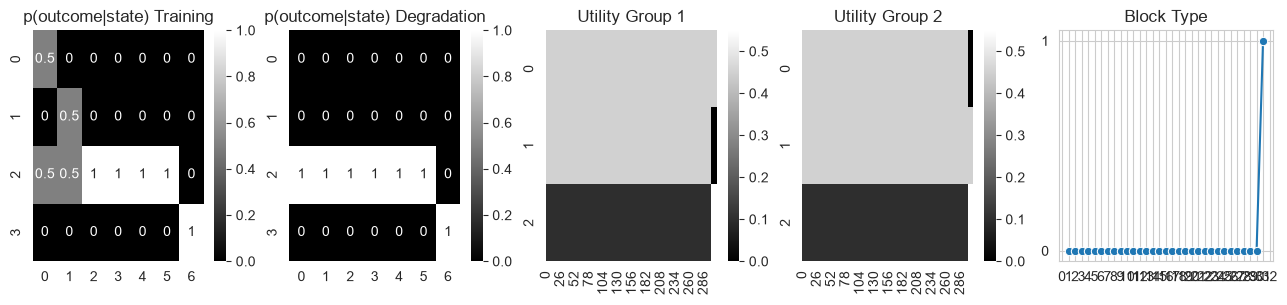

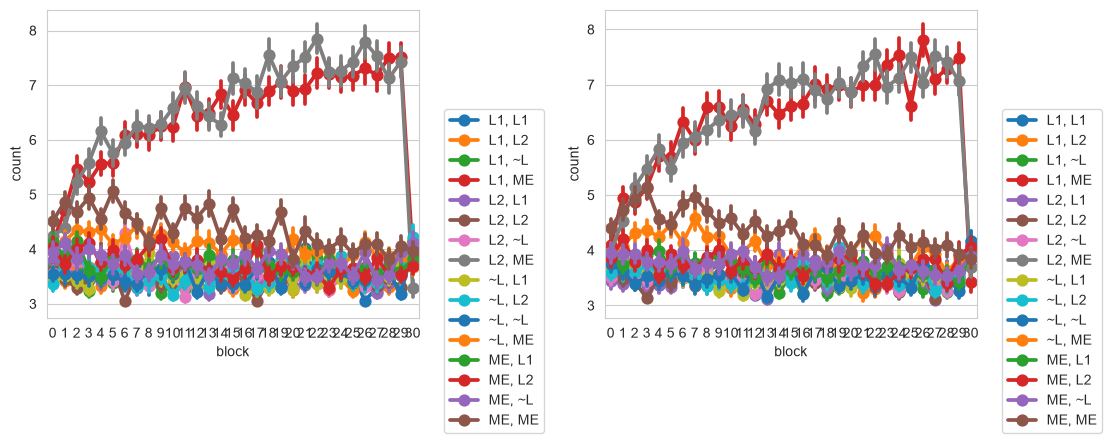

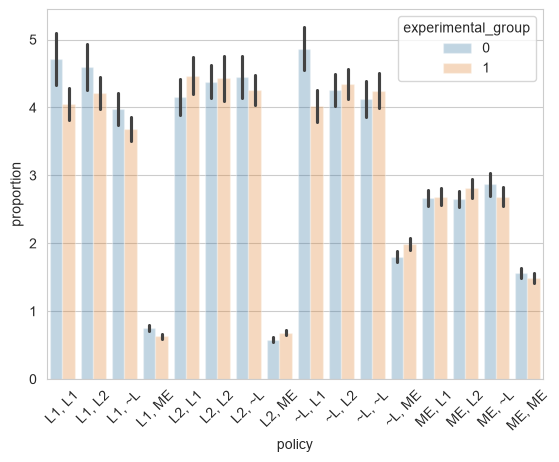

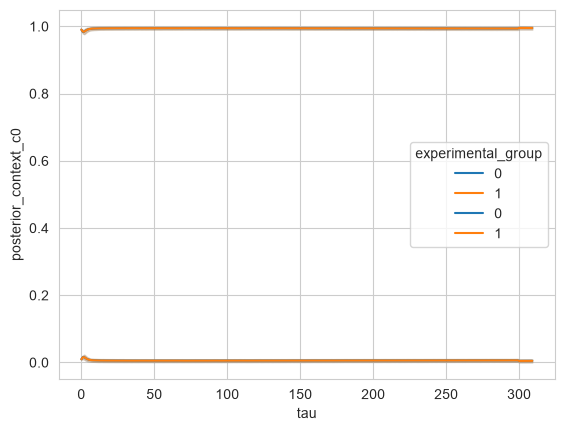

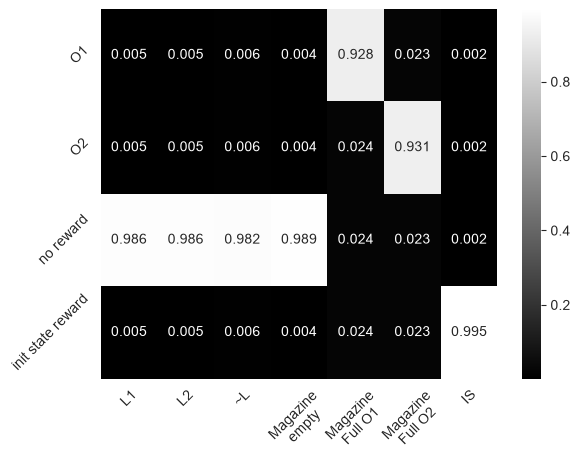

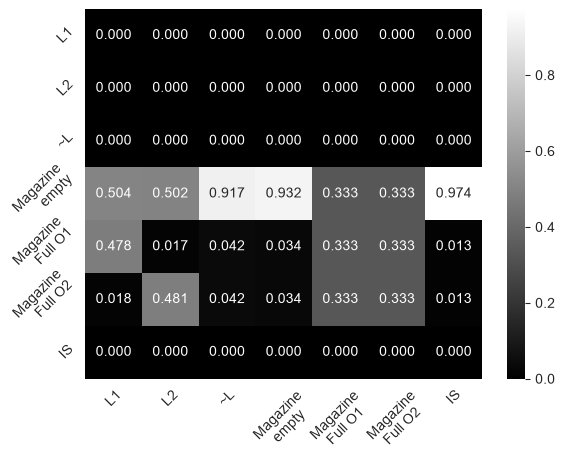

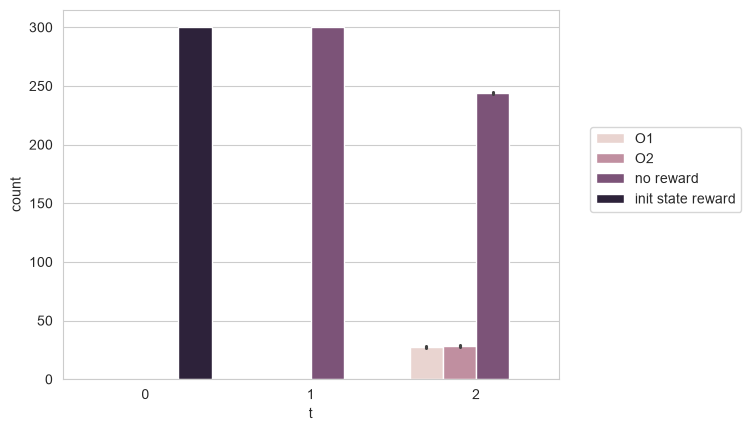

In [10]:
np.random.seed(3)
reps = 200
n_blocks_train = 30
n_blocks_extinction = 1
block_length = 10

n_train = n_blocks_train*block_length
n_extinction = n_blocks_extinction*block_length
TAU = n_train + n_extinction
T = 3  # initial time point, action 1, action 2
na = 4 # L1, L2, ~L, magazine entry
ns = 7 # L1, L2, ~L, empty magazine, full magazine О1, full magazine O2, initial state
nr = 4 # pellet, sugar, no reward, initial state
max_workers = 62
parallel = True
debug = False
p = 0.45
rho_noncontingent = 0.0
rho = 0.5
context_volatility=0.99
h = 1000
dec_temp = 2
habit_exception = None


utility_1 = [[0.45,0.45, 0.1], [p, 0, 1-p]]
utility_2 = [[0.45,0.45, 0.1], [0, p, 1-p]]

# outcomes: O1=pellets, O2=sugar, O3= no reward, O4=starting outcome, probably don't really need it
# states: L1, ~L1, magazine entry, initial state in front lever
Rho = np.stack([[[rho  , 0.0  , 0.0, 0.0, 0.0, 0.0, 0.0],
				 [0.0  , rho  , 0.0, 0.0, 0.0, 0.0, 0.0],
				 [1-rho, 1-rho, 1.0, 1.0, 1.0, 1.0, 0.0],
				 [0.0  , 0.0  , 0.0, 0.0, 0.0, 0.0, 1.0]],
				[[0, 0, 0, 0, 0, 0, 0],
				 [0, 0, 0, 0, 0, 0, 0],
				 [1, 1, 1, 1, 1, 1, 0],
				 [0, 0, 0, 0, 0, 0, 1]]], axis=-1)


long_dfs = []
pars = []
matrices = {"state_transition_matrix": np.zeros([ns,ns,reps*2]), "reward_generation_matrix": np.zeros([nr,ns,reps*2])}

sim = 0
for rep in range(reps):
	for group, util in enumerate([utility_1,utility_2]):
		pars.append({
			"debug": debug, 
			"util": util, 
			"na": na, 
			"ns": ns, 
			"T": T, 
			"n_train": n_train, 
			"n_extinction": n_extinction, 
			"Rho": Rho, 
			"rho_noncontingent": rho_noncontingent,
			"utility_1": utility_1, 
			"utility_2": utility_2,
			"context_volatility": context_volatility, 
			"h": h, 
			"habit_exception": habit_exception,
			"TAU":TAU,
			"sim": sim,
			"group":group,
			"rep": rep,
			"n_blocks_extinction": n_blocks_extinction,
			"n_blocks_train": n_blocks_train,
			"block_length": block_length,
			"state_mapping": {"lever_1_press":0, "lever_2_press":1, "no_lever_press":2, "magazine_empty":3, "magazine_full_O1":4, "magazine_full_O2":5, "initial_state":6},
			"action_mapping": {"lever_1_press":0, "lever_2_press":1, "no_lever_press":2, "magazine_entry":3},
			"reward_mapping": {"outcome_1":0, "outcome_2":1, "no_reward":2, "initial_state":3},
			"action_legend_labels":["L1", "L2", "~L", "ME"],
			"state_legend_labels":["L1", "L2", "~L", "Magazine\nempty","Magazine\nFull O1","Magazine\nFull O2","IS"],
			"reward_legend_labels":["O1","O2","no reward", "init state reward"],
			"dec_temp": 2,
		})
		sim += 1

dfs = []
stm = np.zeros([ns,ns, reps*2])
srm = np.zeros([nr,ns, reps*2])


if parallel == True:
	with ProcessPoolExecutor(max_workers=max_workers) as executor:
		sim_output =  list(executor.map(run_simulation_parallel, pars))

	for si, sim in enumerate(sim_output):
		dfs.append(sim[0])
		stm[:,:,si] = sim[1]
		srm [:,:,si] = sim[2]
	training_protocol = sim[3]	
else:
	long_dfs = []
	sim = 0
	for rep in range(reps):
		for group, util in enumerate([utility_1,utility_2]):
			p  = pars[sim]
			df, stm[:,:,sim], srm[:,:,sim], training_protocol  = run_simulation(debug=p["debug"], utility=p["util"], na=p["na"], ns=p["ns"],\
																				T=p["T"], n_train=p["n_train"], n_extinction=p["n_extinction"],\
																				Rho=p["Rho"], context_volatility=p["context_volatility"],h=p["h"],\
																				habit_exception=p["habit_exception"],pars=p)

			# Create long format dataframe
			dfs.append(df)
			sim += 1

dataframe = pd.concat(dfs)
matrices = {"state_transition_matrix": stm.mean(axis=-1), "reward_generation_matrix": srm.mean(axis=-1)}

plot_results(pars[0], dataframe, matrices, training_protocol)


In [ ]:
df = dataframe.set_index(["experimental_group", "sim", "tau", "t"])
all_inds = np.sort(np.array([list(ind) for ind in df.loc[:,:,0,0].index.to_list()]), axis=0)
inds = []

for group in [0,1]:
    inds.append(all_inds[all_inds[:,0] == group][:,1])

for i in range(10):
    slice = []
    for ind in inds:
        np.random.shuffle(ind)
        group_slice = ind[:500].copy()
        group_slice.sort() 
        slice.append(group_slice)
    slice = np.concat(slice)
    df_plot = df[df.index.get_level_values("sim").isin(slice)]
    df_plot = df_plot.groupby(["experimental_group","sim","phase"])["policy"].value_counts(normalize=True) 
    relative_policy_frequency = (df_plot.loc[:, :, "extinction",:] / df_plot.loc[:, :, "training",:]).reset_index() 
    plt.figure() 
    g = sns.barplot(data=relative_policy_frequency, x="policy", y="proportion", hue="experimental_group", errorbar="se", alpha=0.3) 
    g.xaxis.set_ticklabels(policy_mapping, rotation=45)